In [61]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("respons.csv")

In [62]:
df.columns

Index(['Timestamp',
       'Perkenalan!! Siapa nama Anda? (Boleh nama panggilan atau samaran)',
       'Berapakah usia Anda saat ini? ', 'Apakah gender Anda?',
       'Apa status Anda sekarang? ',
       'Departemen/Jurusan (jika memilih opsi "lainnya", isi dengan "-")',
       'Seberapa sering Anda mengonsumsi minuman berkafein?\n',
       'Jenis minuman berkafein apa yang paling sering Anda konsumsi?\n',
       'Saya menyadari batas konsumsi kafein yang optimal untuk diri saya sendiri',
       'Saya secara sadar mengatur konsumsi kafein berdasarkan kebutuhan akademik ',
       'Seberapa sering Anda mengonsumsi kafein meskipun mengetahui potensi dampak negatifnya?\n',
       'Faktor apa yang paling memengaruhi keputusan Anda dalam mengonsumsi kafein? (pilih 2)\n',
       'Dalam situasi apa Anda paling sering mengonsumsi kafein?\n',
       'Kapan waktu Anda paling sering minum kafein?',
       'Saya merasa lebih sulit tidur pada malam hari jika mengonsumsi kafein pada sore/malam hari '

In [63]:
df['Apakah gender Anda?'].value_counts()

Apakah gender Anda?
Perempuan    123
Laki-laki     10
Name: count, dtype: int64

In [64]:
df["Seberapa sering Anda mengonsumsi minuman berkafein?\n"].value_counts()

Seberapa sering Anda mengonsumsi minuman berkafein?\n
3–5 kali seminggu           46
1–2 kali seminggu           44
Jarang atau tidak pernah    23
Setiap hari                 20
Name: count, dtype: int64

In [65]:
df['Seberapa sering Anda mengonsumsi minuman berkafein?\n'] = \
pd.Categorical(df['Seberapa sering Anda mengonsumsi minuman berkafein?\n'],
                   categories = ['Jarang atau tidak pernah', '1–2 kali seminggu', '3–5 kali seminggu', 'Setiap hari'], 
                   ordered=True)

In [66]:
df["Pernahkah Anda mengalami efek samping setelah mengonsumsi kafein (gelisah, jantung berdebar, susah tidur)? "].value_counts()

Pernahkah Anda mengalami efek samping setelah mengonsumsi kafein (gelisah, jantung berdebar, susah tidur)? 
Kadang-kadang    53
Jarang           29
Sering           26
Tidak pernah     25
Name: count, dtype: int64

In [67]:
df["Pernahkah Anda mengalami efek samping setelah mengonsumsi kafein (gelisah, jantung berdebar, susah tidur)? "] = \
pd.Categorical(df["Pernahkah Anda mengalami efek samping setelah mengonsumsi kafein (gelisah, jantung berdebar, susah tidur)? "],
                   categories = ['Tidak pernah', 'Jarang', 'Kadang-kadang', 'Sering'], 
                   ordered=True)

In [68]:
crosstab1 = pd.crosstab(df["Seberapa sering Anda mengonsumsi minuman berkafein?\n"],
                         df["Pernahkah Anda mengalami efek samping setelah mengonsumsi kafein (gelisah, jantung berdebar, susah tidur)? "])
crosstab1

"Pernahkah Anda mengalami efek samping setelah mengonsumsi kafein (gelisah, jantung berdebar, susah tidur)?",Tidak pernah,Jarang,Kadang-kadang,Sering
Seberapa sering Anda mengonsumsi minuman berkafein?,,,,
Jarang atau tidak pernah,8,2,10,3
1–2 kali seminggu,9,12,14,9
3–5 kali seminggu,8,10,17,11
Setiap hari,0,5,12,3


In [69]:
row_percentages = crosstab1.div(crosstab1.sum(axis=1), axis=0) * 100
row_percentages

"Pernahkah Anda mengalami efek samping setelah mengonsumsi kafein (gelisah, jantung berdebar, susah tidur)?",Tidak pernah,Jarang,Kadang-kadang,Sering
Seberapa sering Anda mengonsumsi minuman berkafein?,,,,
Jarang atau tidak pernah,34.782609,8.695652,43.478261,13.043478
1–2 kali seminggu,20.454545,27.272727,31.818182,20.454545
3–5 kali seminggu,17.391304,21.739130,36.956522,23.913043
Setiap hari,0.000000,25.000000,60.000000,15.000000


<Figure size 1000x600 with 0 Axes>

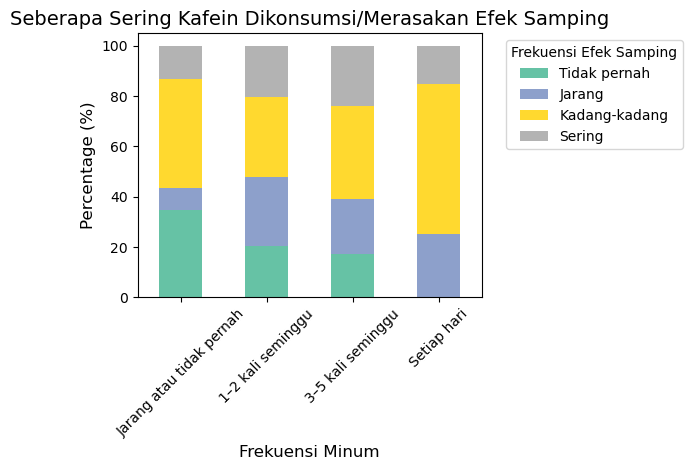

In [70]:
plt.figure(figsize=(10, 6))
ax = row_percentages.plot(kind='bar', stacked=True, colormap='Set2')
plt.title('Seberapa Sering Kafein Dikonsumsi/Merasakan Efek Samping', fontsize=14)
plt.xlabel('Frekuensi Minum', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45)

plt.legend(title='Frekuensi Efek Samping', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Yang jarang atau tidak pernah minum kafein paling banyak menjawab tidak pernah, sedangkan yang minum kafein setiap hari tidak ada yang menjawab 'tidak pernah' sama sekali. <br>

Yang setiap hari minum kafein yang paling banyak menjawab kadang-kadang <br>


Yang menjawab sering naik per kategori sampai pada akhirnya di yang 'setiap hari' menurun (toleransi terhadap kafein)?

In [71]:
df['Seberapa sering Anda mengonsumsi minuman berkafein?\n'].value_counts()

Seberapa sering Anda mengonsumsi minuman berkafein?\n
3–5 kali seminggu           46
1–2 kali seminggu           44
Jarang atau tidak pernah    23
Setiap hari                 20
Name: count, dtype: int64

In [72]:
df['Saya merasa lebih sulit tidur pada malam hari jika mengonsumsi kafein pada sore/malam hari '].value_counts()

Saya merasa lebih sulit tidur pada malam hari jika mengonsumsi kafein pada sore/malam hari 
2    51
4    36
3    18
5    14
1    14
Name: count, dtype: int64

In [ ]:
sleep_map = {
    1 : 'Sangat Tidak Setuju',
    2 : 'Tidak Setuju',
    3 : 'Netral',
    4 : 'Setuju',
    5 : 'Sangat Setuju'
}

df['sulit_tidur_map'] = df['Saya merasa lebih sulit tidur pada malam' \
' hari jika mengonsumsi kafein pada sore/malam hari '].map(sleep_map)

,Timestamp,Perkenalan!! Siapa nama Anda? (Boleh nama panggilan atau samaran),Berapakah usia Anda saat ini?,Apakah gender Anda?,Apa status Anda sekarang?,"Departemen/Jurusan (jika memilih opsi ""lainnya"", isi dengan ""-"")",Seberapa sering Anda mengonsumsi minuman berkafein?\n,Jenis minuman berkafein apa yang paling sering Anda konsumsi?\n,Saya menyadari batas konsumsi kafein yang optimal untuk diri saya sendiri,Saya secara sadar mengatur konsumsi kafein berdasarkan kebutuhan akademik,...,Anda lebih memilih penyampaian informasi melalui:,Seberapa penting peran karakter dalam membantu Anda memahami materi?,"Seberapa penting pengaruh visual (illustrasi, ekspresi karakter, tampilan antarmuka) dalam membantu Anda memahami cerita?","Menurut Anda, apa yang perlu diperhatikan agar media edukasi tentang konsumsi kafein menjadi menarik dan efektif?",Ceritakan pengalaman Anda terkait konsumsi kafein yang paling memengaruhi performa belajar atau daya ingat Anda! (Opsional),"Menurut Anda, bagaimana cara terbaik menyampaikan informasi ilmiah agar tidak terasa membosankan? (Opsional)\n","Jika Anda menjadi perancang media ini, fitur apa yang akan Anda prioritaskan dan mengapa? (Opsional)\n",(Opsional) Akun media sosial/nomor telepon WhatsApp yang dapat dihubungi + platformnya (misal: @user123 Instagram),"Jika Anda mengonsumsi kopi, jenis kopi apa yang paling sering Anda pilih?",sulit_tidur_map
0,05/04/2026 20:49:23,Wisnuu,18-21 tahun,Perempuan,Lainnya,-,3–5 kali seminggu,Kopi,Sangat sadar,Sangat sadar,...,Kombinasi dari seluruh pilihan di atas,Sangat penting,Sangat penting,Membuat info grafis berbentuk poster yang menc...,Saya kadang mengonsumsi sampai 5 dosis kopi sa...,infografis,infografis yang berbentuk ppt,085956442775 + wiwisn_u (ig),Kopi instan/sachet,Netral
1,05/04/2026 20:49:58,Niramine,18-21 tahun,Perempuan,Lainnya,-,Setiap hari,Kopi,Sangat sadar,Sangat sadar,...,Kombinasi dari seluruh pilihan di atas,Sangat penting,Sangat penting,"Sangat perlu, menurut saya dengan memperhatika...",Kafein membuat saya terbangun dan fokus dalam ...,Dengan ilustrasi dan karakter yang menarik ser...,Lebih mendominankan penyampaian melalui media ...,0822 8778 4798(@chassneeja),"Kopi dengan tambahan (misal vanilla, karamel, ...",Sangat Setuju
2,05/04/2026 20:51:54,Najla chan :3,18-21 tahun,Perempuan,Lainnya,DKV,3–5 kali seminggu,Teh,Kurang sadar,Kurang sadar,...,Visual/infografis dalam game,Sangat penting,Sangat penting,Plot cerita yg matang dan visual yang enak dil...,Jujur gak tau gak inget 😭,Sebenernya pengamgkatan jadi Visual Novel udah...,Plot cerita dan yang mencakup Visual,Ini Najla Peses 😛 tau lah ya,Kopi instan/sachet,Setuju
3,05/04/2026 20:55:51,Raura,<18 tahun,Perempuan,Lainnya,-,Jarang atau tidak pernah,Teh,Sangat sadar,Kurang sadar,...,Kombinasi dari seluruh pilihan di atas,Sangat penting,Sangat penting,Pendekatan dapat dilakukan dengan media releva...,NaN,NaN,NaN,@rakouraaa Instagram,Kopi hitam tanpa tambahan (gula atau krimer),Sangat Tidak Setuju
4,05/04/2026 20:58:06,Prisil,18-21 tahun,Perempuan,Lainnya,-,Setiap hari,Kopi,Sadar,Kurang sadar,...,Kombinasi dari seluruh pilihan di atas,Sangat penting,Sangat penting,Menurut saya bisa lebih ditekankan efek negati...,NaN,NaN,NaN,@per_kedelz (IG),"Kopi dengan tambahan (misal vanilla, karamel, ...",Sangat Tidak Setuju


In [74]:
df['sulit_tidur_map'] = pd.Categorical(df['sulit_tidur_map'], categories = [
    'Sangat Tidak Setuju', 'Tidak Setuju', 'Netral', 'Setuju', 'Sangat Setuju'], 
    ordered = True)

crosstab2 = pd.crosstab(df["Seberapa sering Anda mengonsumsi minuman berkafein?\n"],
                         df["sulit_tidur_map"])
crosstab2

sulit_tidur_map,Sangat Tidak Setuju,Tidak Setuju,Netral,Setuju,Sangat Setuju
Seberapa sering Anda mengonsumsi minuman berkafein?,,,,,
Jarang atau tidak pernah,6,8,1,6,2
1–2 kali seminggu,4,15,6,13,6
3–5 kali seminggu,2,21,7,11,5
Setiap hari,2,7,4,6,1


In [75]:
row_percentages1 = crosstab2.div(crosstab2.sum(axis=1), axis =0) * 100
row_percentages1

sulit_tidur_map,Sangat Tidak Setuju,Tidak Setuju,Netral,Setuju,Sangat Setuju
Seberapa sering Anda mengonsumsi minuman berkafein?,,,,,
Jarang atau tidak pernah,26.086957,34.782609,4.347826,26.086957,8.695652
1–2 kali seminggu,9.090909,34.090909,13.636364,29.545455,13.636364
3–5 kali seminggu,4.347826,45.652174,15.217391,23.913043,10.869565
Setiap hari,10.000000,35.000000,20.000000,30.000000,5.000000


<Figure size 1000x600 with 0 Axes>

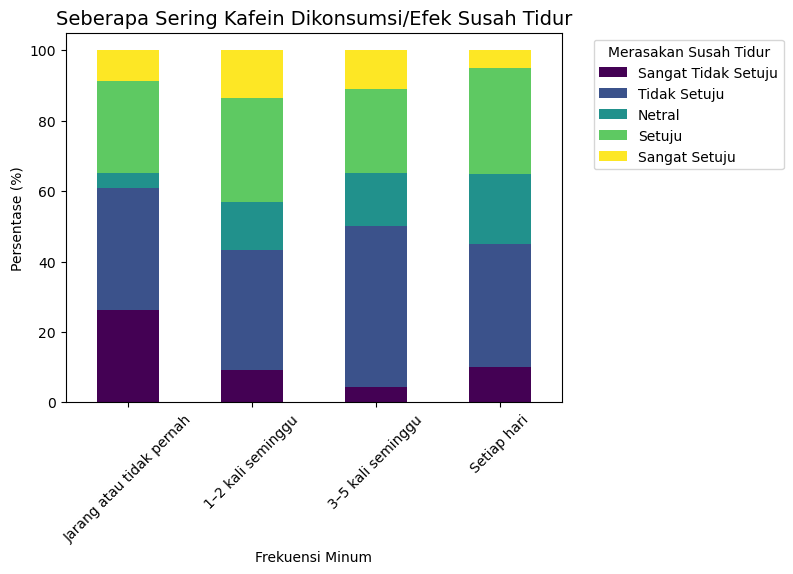

In [76]:
plt.figure(figsize=(10, 6))
ax = row_percentages1.plot(kind = 'bar', stacked = True, colormap = 'viridis')
plt.title('Seberapa Sering Kafein Dikonsumsi/Efek Susah Tidur', fontsize=14)
plt.xlabel('Frekuensi Minum')
plt.ylabel('Persentase (%)')
plt.xticks(rotation=45)

plt.legend(title='Merasakan Susah Tidur',bbox_to_anchor= (1.05, 1), loc = 'upper left')
plt.show()

Yang 'setiap hari' 30% "Setuju" merasakan susah tidur, tapi 35% "Tidak Setuju" <br>
Yang jarang atau tidak pernah paling banyak menjawab sangat tidak setuju + tidak setuju. <br>
Namun, jika yang paling banyak menjawab setuju + sangat setuju adalah yang 1-2 kali seminggu minum kafein. <br>
Yang jarang, 3-5 kali seminggu, dan setiap hari semuanya mirip dalam konteks setuju + sangat setuju. <br>

Belum ada pola yang jelas.